# **Data preparation for training**

Investigate dataset and prepare the dataset for binary classification.

# **Import the required libraries**

In [10]:
import pandas
import numpy
import random
from sklearn.model_selection import train_test_split

# Just for clearing the outputs, removing Python warnings.
import warnings
warnings.filterwarnings("ignore")

In [11]:
# Define random seeds for reproducibility
SEED: int = 42
random.seed(SEED)
numpy.random.seed(SEED)

# **Load the raw dataset**

In [12]:
# Home Equity Loan dataset from SAS
# https://support.sas.com/documentation/onlinedoc/viya/examples.htm

original_data: pandas.DataFrame = pandas.read_csv("hmeq.csv")
original_data.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


In [13]:
original_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB


In [14]:
print("Null values count:")
print(original_data.isnull().sum())

Null values count:
BAD           0
LOAN          0
MORTDUE     518
VALUE       112
REASON      252
JOB         279
YOJ         515
DEROG       708
DELINQ      580
CLAGE       308
NINQ        510
CLNO        222
DEBTINC    1267
dtype: int64


In [15]:
print("Is there any duplications:")
print(original_data.duplicated().any())

Is there any duplications:
False


# **Investigate the target variable**

Target label samples count:
BAD
0    4771
1    1189
Name: count, dtype: int64
Target label No Diabates percentage:: 80.05%
Target label Diabetes percentage: 19.95%


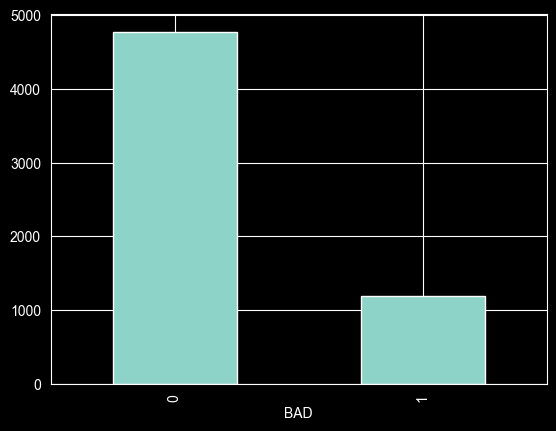

In [16]:
outcome_values: pandas.Series = original_data["BAD"].value_counts()
outcome_values.plot(kind="bar")

print("Target label samples count:")
print(original_data["BAD"].value_counts())

print(f"Target label No Diabates percentage:: {round(outcome_values[0] / original_data['BAD'].count() * 100, 2)}%")
print(f"Target label Diabetes percentage: {round(outcome_values[1] / original_data['BAD'].count() * 100, 2)}%")

In [17]:
original_data.describe()

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,5960.000000,5960.000000,5442.000000,5848.000000,5445.000000,5252.000000,5380.000000,5652.000000,5450.000000,5738.000000,4693.000000
mean,0.199497,18607.969799,73760.817200,101776.048741,8.922268,0.254570,0.449442,179.766275,1.186055,21.296096,33.779915
std,0.399656,11207.480417,44457.609458,57385.775334,7.573982,0.846047,1.127266,85.810092,1.728675,10.138933,8.601746
min,0.000000,1100.000000,2063.000000,8000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.524499
25%,0.000000,11100.000000,46276.000000,66075.500000,3.000000,0.000000,0.000000,115.116702,0.000000,15.000000,29.140031
50%,0.000000,16300.000000,65019.000000,89235.500000,7.000000,0.000000,0.000000,173.466667,1.000000,20.000000,34.818262
75%,0.000000,23300.000000,91488.000000,119824.250000,13.000000,0.000000,0.000000,231.562278,2.000000,26.000000,39.003141
max,1.000000,89900.000000,399550.000000,855909.000000,41.000000,10.000000,15.000000,1168.233561,17.000000,71.000000,203.312149


In [18]:
# Numerical and categorical columns separation
num_cols = original_data.select_dtypes(include=[numpy.number]).columns
cat_cols = original_data.select_dtypes(include=['object']).columns

# Numerical imputation with median
for col in num_cols:
    original_data[col] = original_data[col].fillna(original_data[col].median())

# Categorical imputation with mode
for col in cat_cols:
    original_data[col] = original_data[col].fillna(original_data[col].mode()[0])

In [19]:
# One-Hot Encoding (Dummy variables)
original_data = pandas.get_dummies(original_data, columns=['REASON', 'JOB'], drop_first=True)

In [22]:
# Numerical (continuous)
continuous_vars = original_data.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical
categorical_vars = original_data.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print(f"Continuous variables ({len(continuous_vars)}):")
print(continuous_vars)

print(f"\nCategorical variables ({len(categorical_vars)}):")
print(categorical_vars)

Continuous variables (11):
['BAD', 'LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC']

Categorical variables (6):
['REASON_HomeImp', 'JOB_Office', 'JOB_Other', 'JOB_ProfExe', 'JOB_Sales', 'JOB_Self']


In [20]:
train_df, test_df = train_test_split(
    original_data,
    test_size=0.3,
    random_state=SEED,
    stratify=original_data["BAD"]
)

train_df.to_csv("hmeq_preprocessed_train_data.csv", index=False, float_format="%.6f")
test_df.to_csv("hmeq_preprocessed_test_data.csv", index=False, float_format="%.6f")